# Customer Segmentation Analysis

## Project Overview
The objective of this project is to perform customer segmentation analysis for an e-commerce business. Customer segmentation helps in understanding different groups of customers based on their purchasing behavior and characteristics. By grouping customers into meaningful segments, businesses can design targeted marketing strategies, improve customer satisfaction, and optimize overall business performance.

## Dataset Description
The dataset used in this project contains customer-related information such as spending behavior and purchasing patterns. This data will be analyzed to identify distinct customer segments using clustering techniques.

## Objectives of the Analysis
- To explore and understand customer purchase behavior
- To perform data cleaning and preprocessing
- To apply clustering algorithms for customer segmentation
- To visualize customer segments
- To derive business insights and recommendations based on the segments

In [1]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the dataset
df = pd.read_csv("Mall_Customers.csv")

# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Dataset shape (rows, columns)
df.shape

(200, 5)

In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
# Summary statistics
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Data Exploration Summary

- The dataset contains customer demographic and spending-related information.
- Numerical features include Age, Annual Income, and Spending Score.
- There are no missing values observed in the dataset.
- These features are suitable for customer segmentation analysis using clustering techniques.

In [6]:
# Check for missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
# Selecting features for clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [9]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Data Cleaning and Preprocessing

- Checked for missing values and duplicate records in the dataset.
- Selected relevant numerical features for customer segmentation.
- Applied feature scaling to normalize the data before clustering.
- Preprocessing ensures accurate distance-based clustering results.

In [10]:
# Descriptive statistics for customer features
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [11]:
# Mean
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

# Median
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].median()

# Mode
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mode().iloc[0]

# Standard Deviation
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].std()

Age                       13.969007
Annual Income (k$)        26.264721
Spending Score (1-100)    25.823522
dtype: float64

## Descriptive Statistics Summary

- The average age of customers represents a mixed demographic group.
- Annual income values show variation among customers, indicating different purchasing capacities.
- Spending scores highlight different spending behaviors among customers.
- These statistics help in understanding customer diversity before segmentation.

C:\Users\Jinal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Jinal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Jinal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Jinal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

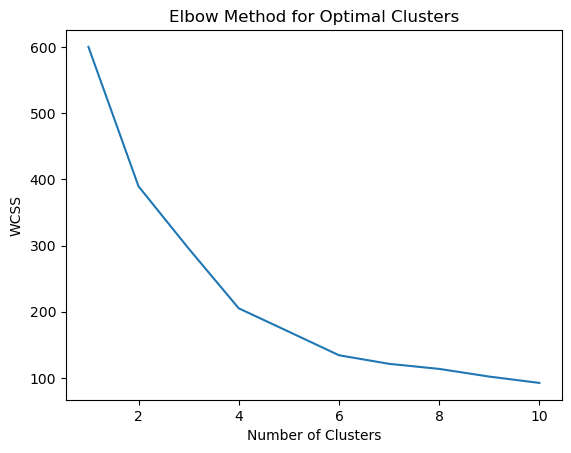

In [12]:
# Using the Elbow Method to find optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure()
plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

In [13]:
# Applying K-Means with optimal number of clusters

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\Jinal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [14]:
# Number of customers in each cluster
df['Cluster'].value_counts()

Cluster
0    58
3    45
1    40
4    31
2    26
Name: count, dtype: int64

## Customer Segmentation Using K-Means

- The Elbow Method was used to determine the optimal number of customer segments.
- K-Means clustering was applied to group customers based on age, income, and spending behavior.
- Each customer was assigned to a specific cluster representing similar characteristics.
- These clusters enable businesses to identify distinct customer groups for targeted strategies.

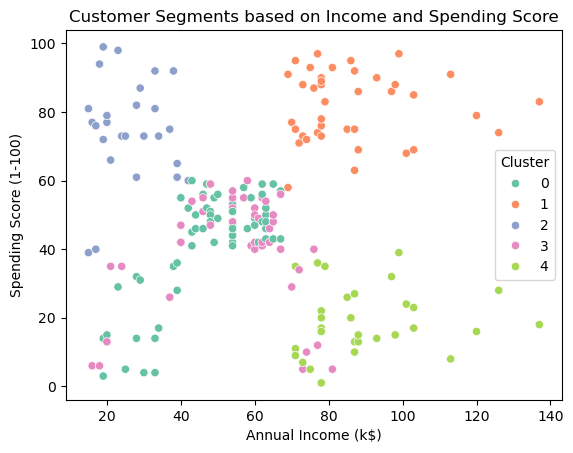

In [15]:
# Visualizing customer segments based on Income and Spending Score
plt.figure()
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set2'
)
plt.title('Customer Segments based on Income and Spending Score')
plt.show()

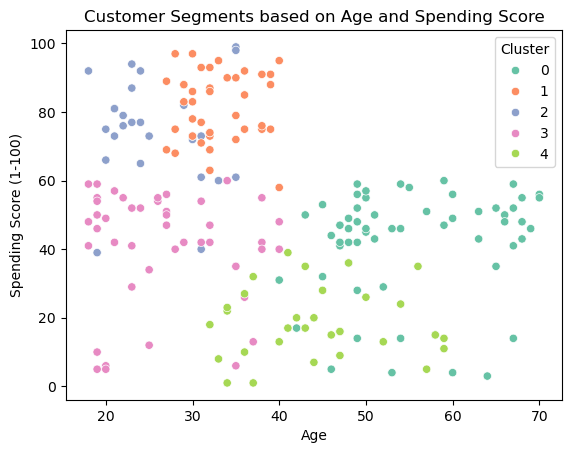

In [16]:
# Visualizing customer segments based on Age and Spending Score
plt.figure()
sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set2'
)
plt.title('Customer Segments based on Age and Spending Score')
plt.show()

## Visualization of Customer Segments

- Scatter plots clearly illustrate distinct customer clusters.
- Customers within the same cluster exhibit similar spending and income patterns.
- These visualizations help identify high-value and low-value customer groups.
- Visual analysis supports strategic decision-making and targeted marketing.

In [17]:
# Analyzing average values for each cluster
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


## Insights and Recommendations

### Cluster 0
- Customers in this segment have moderate income and spending levels.
- Recommendation: Target with balanced promotional offers.

### Cluster 1
- Customers have high income and high spending scores.
- Recommendation: Focus on premium products and loyalty programs.

### Cluster 2
- Customers in this segment have low annual income but high spending scores.
- Recommendation: Focus on affordable products, student-friendly offers, and frequent promotions to maintain engagement.

### Cluster 3
- Customers in this segment have moderate income and moderate to low spending scores.
- Recommendation: Use targeted discounts and engagement campaigns to gradually increase spending.

### Cluster 4
- Customers in this segment have high annual income but low spending scores.
- Recommendation: Use personalized and premium-focused marketing strategies to encourage increased spending.

## Conclusion

Customer segmentation helps businesses target customers effectively and improve marketing strategies.